# Analisi dei Modelli PEFT (Soft Prompt / Prefix Tuning)
Questo notebook esegue l'analisi visiva e quantitativa dei token virtuali appresi durante l'addestramento, includendo l'analisi geometrica lineare (PCA) e non lineare (t-SNE), la similarità cosinale rispetto al vocabolario e il calcolo dell'entropia rinormalizzata delle mappe di attenzione.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from trainer import prepare_data
from soft_ner_model import NERSoftPromptModel
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch.nn.functional as F
from seqeval.metrics import f1_score, classification_report
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.metrics.pairwise import cosine_similarity
import os
from model_analysis_extensions import (
    per_class_report,
    entity_error_analysis,
    trainable_parameter_report,
    compare_peft_results,
    compare_peft_with_baseline,
    hyperparameter_heatmaps,
    cumulative_ablation_analysis,
    attention_by_gold_label,
)


C:\Users\Franco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Funzioni di Utilità (Helpers)

In [2]:
def forward_custom(model, input_ids, attention_mask,
                   prefix_override=None, output_attentions=False):
    """
    Run the model, optionally replacing the prefix with a given one.
    """
    bsz = input_ids.shape[0]
    if prefix_override is None:
        prefix = model.prefix_module(bsz=bsz)
    else:
        prefix = prefix_override.expand(bsz, -1, -1)

    inp_emb = model.encoder.get_input_embeddings()(input_ids)
    enc_in  = torch.cat([prefix, inp_emb], dim=1)

    pref_mask = torch.ones(bsz, prefix.shape[1], device=input_ids.device)
    full_mask = torch.cat([pref_mask, attention_mask], dim=1)

    out = model.encoder(inputs_embeds=enc_in,
                        attention_mask=full_mask,
                        output_attentions=output_attentions)
    text_hidden = out.last_hidden_state[:, prefix.shape[1]:]
    logits = model.classifier(text_hidden)
    return logits, out


def compute_f1(model, loader, device, id_to_tag,
               prefix_override=None, print_report=False):

    model.eval()
    true_labels, predicted_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn      = batch['attention_mask'].to(device)
            labels    = batch['labels'].to(device)

            logits, _ = forward_custom(model, input_ids, attn,
                                       prefix_override=prefix_override)
            preds = logits.argmax(-1)

            for i in range(labels.shape[0]):
                t_tags, p_tags = [], []
                for j in range(labels.shape[1]):
                    if labels[i, j] != -100:
                        t_tags.append(id_to_tag[labels[i, j].item()])
                        p_tags.append(id_to_tag[preds[i, j].item()])
                true_labels.append(t_tags)
                predicted_labels.append(p_tags)

    if print_report:
        print(classification_report(true_labels, predicted_labels, digits=4))

    current_f1 = f1_score(true_labels, predicted_labels)
    return current_f1

def _convert_loader_to_list(loader):
    batches = []
    for batch in loader:
        batches.append(batch)
    return batches

def _list_to_loader(batches):
    class BatchIterator:
        def __init__(self, batch_list):
            self.batches = batch_list
        def __iter__(self):
            return iter(self.batches)
    return BatchIterator(batches)

### Funzioni di Analisi

In [3]:
def pca_analysis(model, n_vocab=5000, seed=0, file_name=""):
    """Proietta in 2D i soft token insieme a un campione del vocabolario tramite PCA."""
    rng = np.random.default_rng(seed)
    model.eval()
    with torch.no_grad():
        # Soft token realmente usati dall'encoder, dopo la trasformazione del prefix module.
        prefix = model.prefix_module(bsz=1).squeeze(0).cpu().numpy()          # (L, H)
        # Embedding statici del vocabolario del modello backbone.
        vocab  = model.encoder.get_input_embeddings().weight.cpu().numpy()    # (V, H)

    idx = rng.choice(vocab.shape[0], size=min(n_vocab, vocab.shape[0]), replace=False)
    vocab_s = vocab[idx]

    # PCA viene stimata su vocabolario campionato + soft token nello stesso spazio H-dimensionale.
    points = np.vstack([vocab_s, prefix])                                    # (n_vocab + L, H)
    proj = PCA(n_components=2).fit_transform(points)                         # (n_vocab + L, 2)
    v2d, p2d = proj[:len(vocab_s)], proj[len(vocab_s):]

    plt.figure(figsize=(8, 7))
    plt.scatter(v2d[:, 0], v2d[:, 1], alpha=0.25, s=6, label="Vocabulary")
    plt.scatter(p2d[:, 0], p2d[:, 1], color="red", s=60, marker="x", label="Prefix tokens")
    for i, (x, y) in enumerate(p2d):
        plt.annotate(str(i), (x, y), fontsize=7)
    plt.legend(); plt.title("Prefix embeddings vs vocabulary (PCA)")
    file_name = file_name.removesuffix(".pth")
    plt.tight_layout(); plt.savefig("output_analysis/pca_" + file_name + ".png" , dpi=120); plt.show()

In [4]:
def tsne_analysis(model, n_vocab=5000, seed=0, file_name=""):
    """Proietta in 2D i soft token e il vocabolario con t-SNE, preservando vicinanze locali."""
    rng = np.random.default_rng(seed)
    model.eval()
    with torch.no_grad():
        # Soft token realmente inseriti prima del testo nell'encoder.
        prefix = model.prefix_module(bsz=1).squeeze(0).cpu().numpy()          # (L, H)
        # Embedding del vocabolario del modello usati come riferimento geometrico.
        vocab  = model.encoder.get_input_embeddings().weight.cpu().numpy()    # (V, H)

    # Piccola porzione del vocaboriario
    idx = rng.choice(vocab.shape[0], size=min(n_vocab, vocab.shape[0]), replace=False)
    vocab_s = vocab[idx]

    points = np.vstack([vocab_s, prefix])                                    # (n_vocab + L, H)
    if len(points) <= 1:
        raise ValueError("t-SNE richiede almeno 2 punti tra vocabolario campionato e soft token.")
    # La perplexity deve essere minore del numero di punti
    perplexity = min(15, len(points) - 1)
    proj = TSNE(n_components=2, perplexity=perplexity, random_state=seed, max_iter=1000).fit_transform(points)
    # Separa le coordinate 2D del vocabolario da quelle dei soft token.
    v2d, p2d = proj[:len(vocab_s)], proj[len(vocab_s):]

    plt.figure(figsize=(8, 7))
    plt.scatter(v2d[:, 0], v2d[:, 1], alpha=0.25, s=6, label="Vocabulary", color="lightblue")
    plt.scatter(p2d[:, 0], p2d[:, 1], color="red", s=60, marker="x", label="Prefix tokens")
    for i, (x, y) in enumerate(p2d):
        plt.annotate(str(i), (x, y), fontsize=7)
    plt.legend(); plt.title("Prefix embeddings vs vocabulary (t-SNE)")
    file_name = file_name.removesuffix(".pth")
    plt.tight_layout(); plt.savefig("output_analysis/tsne_" + file_name + ".png" , dpi=120); plt.show()


In [5]:
def cosine_similarity_distribution(model, file_name=""):
    """Calcola la distribuzione statistica della similarità cosinale rispetto al vocabolario."""
    model.eval()
    with torch.no_grad():
        # Soft token  prodotti dal module
        soft_embeddings = model.prefix_module(bsz=1).squeeze(0)               # (L, H)
        # Embedding del vocabolario del modello backbone.
        word_embeddings = model.encoder.get_input_embeddings().weight         # (V, H)
        
        soft_norm = F.normalize(soft_embeddings, dim=-1)
        word_norm = F.normalize(word_embeddings, dim=-1)
        
        # Matrice L x V: ogni cella confronta un soft token con un token del vocabolario.
        similarity_matrix = torch.matmul(soft_norm, word_norm.T).cpu().numpy() # (L, V)
        # Per ogni soft token prendiamo il vicino lessicale piu simile nel vocabolario.
        max_similarities = np.max(similarity_matrix, axis=1)

        plt.figure(figsize=(8, 5))
        plt.hist(max_similarities, bins=15, alpha=0.7, edgecolor='black')
        plt.axvline(np.mean(max_similarities), color='red', linestyle='dashed', label=f'Media: {np.mean(max_similarities):.3f}')
        plt.xlabel('Massima Cosine Similarity'); plt.ylabel('Frequenza (Conteggio dei Token Virtuali)')
        plt.title('Distribuzione della Massima Affinità Semantica dei Prompt')
        plt.legend()
        file_name = file_name.removesuffix(".pth")
        plt.tight_layout(); plt.savefig("output_analysis/cosine_" + file_name + ".png", dpi=120); plt.show()

In [6]:
def attention_analysis(model, val_loader, device, n_batches=5, file_name=""):
    """How much do real tokens attend to each prefix position?"""
    model.eval()
    prefix_len = model.prefix_module.preseqlen
    total = torch.zeros(prefix_len)
    n = 0

    with torch.no_grad():
        for b, batch in enumerate(val_loader):
            if b >= n_batches:
                break
            input_ids = batch['input_ids'].to(device)
            attn      = batch['attention_mask'].to(device)

            _, enc_out = forward_custom(model, input_ids, attn, output_attentions=True)
            a = torch.stack(enc_out.attentions)               # (L, B, H, S, S)
            to_prefix = a[:, :, :, prefix_len:, :prefix_len]  # (L, B, H, real, pref)
            total += to_prefix.mean(dim=(0, 1, 2, 3)).cpu()
            n += 1

    avg = total / n
    plt.figure(figsize=(12, 4))
    plt.bar(range(prefix_len), avg.numpy())
    plt.xlabel("Prefix position"); plt.ylabel("Avg attention received")
    plt.title("Which prefix positions do real tokens attend to?")
    file_name = file_name.removesuffix(".pth")
    plt.tight_layout(); plt.savefig("output_analysis/attention_" + file_name +".png", dpi=120); plt.show()
    return avg


In [7]:
def attention_entropy_analysis(model, val_loader, device, n_batches=5):
    model.eval()
    all_entropies = []
    prefix_len = model.prefix_module.preseqlen
    
    with torch.no_grad():
        for b, batch in enumerate(val_loader):
            if b >= n_batches:
                break
            input_ids = batch['input_ids'].to(device)
            attn      = batch['attention_mask'].to(device)
            
            _, enc_out = forward_custom(model, input_ids, attn, output_attentions=True)
            last_layer_attn = enc_out.attentions[-1]                         # (B, heads, seq, seq)
            to_prefix = last_layer_attn[:, :, prefix_len:, :prefix_len]      # (B, heads, real, pref)
            
            to_prefix_sum = to_prefix.sum(dim=-1, keepdim=True) + 1e-12
            to_prefix_probs = (to_prefix / to_prefix_sum).cpu().numpy() + 1e-12
            
            entropy = -np.sum(to_prefix_probs * np.log(to_prefix_probs), axis=-1)
            all_entropies.append(entropy.mean())
            
    print(f"\nEntropia Media dell'Attenzione verso i Prompt: {np.mean(all_entropies):.4f}")

In [8]:
def ablation_analysis(model, val_loader, device, id_to_tag, file_name = ""):
    """Zero out one prefix position at a time, measure F1 drop."""
    print("Converting DataLoader to batch list (this may take a moment)...")
    batches = _convert_loader_to_list(val_loader)
    batch_loader = _list_to_loader(batches)
    
    baseline = compute_f1(model, batch_loader, device, id_to_tag)
    print(f"Baseline F1: {baseline:.4f}")

    log_lines = []
    log_lines.append(f"Baseline F1: {baseline:.4f}")
    
    prefix_len = model.prefix_module.preseqlen
    with torch.no_grad():
        full_prefix = model.prefix_module(bsz=1)     # (1, L, H)

    drops = []
    for i in range(prefix_len):
        ablated = full_prefix.clone()
        ablated[:, i, :] = 0
        batch_loader = _list_to_loader(batches)
        f1 = compute_f1(model, batch_loader, device, id_to_tag, prefix_override=ablated)
        drops.append(baseline - f1)
        temp =f"  position {i:02d}: F1 = {f1:.4f}  (drop = {baseline - f1:+.4f})"
        print(temp)
        log_lines.append(temp)


    file_name = file_name.removesuffix(".pth")
    os.makedirs("output_analysis", exist_ok=True)
    with open("output_analysis/ablation_" + file_name + ".txt", "w", encoding="utf-8") as f:
        f.write("\n".join(log_lines) + "\n")
    
    plt.figure(figsize=(12, 4))
    plt.bar(range(prefix_len), drops)
    plt.xlabel("Prefix position"); plt.ylabel("F1 drop when ablated")
    plt.title("Importance of each prefix position")
    plt.tight_layout(); plt.savefig("output_analysis/ablation_" + file_name + ".png", dpi=120); plt.show()
    return drops

In [17]:
def cluster_soft_tokens(model, file_name, n_clusters=3):
    """
    Esegue il Clustering Gerarchico sui soft token per identificare gruppi funzionali interni.
    Genera il Dendrogramma e la Heatmap ordinata della matrice di affinità.

    """
    model.eval()
    with torch.no_grad():
        # Embedding dei soft token (L x H)
        soft_embeddings = model.prefix_module(bsz=1).squeeze(0).cpu().numpy()
    
    L, H = soft_embeddings.shape
    print(f"Estrazione completata: {L} soft token con dimensionalità {H}")
    
    # 2. Matrice di similarita (L x L)
    similarity_matrix = cosine_similarity(soft_embeddings)
    
    distance_matrix = 1.0 - similarity_matrix
    distance_matrix = np.clip(distance_matrix, 0.0, 2.0)
    
    # Clustering Gerarchico
    from scipy.spatial.distance import squareform
    condensed_distances = squareform(distance_matrix, checks=False)
    Z = linkage(condensed_distances, method='ward')
    
    cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    
    # Dendrogramma
    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=np.arange(1, L + 1), leaf_rotation=90, leaf_font_size=10)
    plt.axhline(y=Z[-n_clusters+1, 2], color='r', linestyle='--', label=f'{n_clusters} Cluster Taglio')
    plt.title(f"Dendrogramma dei Soft Token\n({file_name.split('/')[-1]})")
    plt.xlabel("Indice del Virtual Token")
    plt.ylabel("Distanza di Collegamento (Ward)")
    plt.legend()
    plt.tight_layout()
    file_name = file_name.removesuffix(".pth")
    plt.savefig("output_analysis/clustering_" + file_name +".png", dpi=120)
    plt.show()
    
    # Serve per raggruppare i token vicini visivamente nella heatmap
    sorted_indices = np.argsort(cluster_labels)
    sorted_similarity = similarity_matrix[sorted_indices][:, sorted_indices]
    
    # Heatmap della Matrice di Affinita Clustered
    plt.figure(figsize=(8, 7))
    sns.heatmap(sorted_similarity, 
                cmap='viridis', 
                xticklabels=sorted_indices + 1, 
                yticklabels=sorted_indices + 1,
                cbar_kws={'label': 'Cosine Similarity'})
    plt.title(f"Matrice di Autosimilarità Riordinata per Cluster")
    plt.xlabel("Indice dei Virtual Token")
    plt.ylabel("Indice dei Virtual Token")
    plt.tight_layout()
    plt.savefig("output_analysis/heatmap_clustering_" + file_name +".png", dpi=120)
    plt.show()
    
    log_lines = []
    
    # Stampiano la composizione dei cluster sul terminale
    print("\n=== COMPOSIZIONE DEI CLUSTER STRUTTURALI ===")
    for c in range(1, n_clusters + 1):
        tokens_in_cluster = np.where(cluster_labels == c)[0] + 1
        temp = f"Cluster {c:02d} (Dimensione: {len(tokens_in_cluster)} token): {list(tokens_in_cluster)}"
        print(temp)
        log_lines.append(temp)
    
    
    os.makedirs("output_analysis", exist_ok=True)
    with open("output_analysis/cluster_" + file_name + ".txt", "w", encoding="utf-8") as f:
        f.write("\n".join(log_lines) + "\n")
        
    return cluster_labels, similarity_matrix

### Configurazione Parametri ed Esecuzione Pipeline

In [10]:
MODEL_NAME = 'dmis-lab/biobert-v1.1'
DATASET_NAME = 'disi-unibo-nlp/bc5cdr'
PREFIX_LENGTH = 50
MAX_SEQ_LEN = 128
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

device = torch.device(DEVICE)
clean_model_name = MODEL_NAME.split('/')[-1]
clean_dataset_name = DATASET_NAME.split('/')[-1]
file_name = f"model_{clean_model_name}_{clean_dataset_name}_len{PREFIX_LENGTH}_lr{LEARNING_RATE}.pth"

print(f"Dispositivo target: {device}")
print(f"File checkpoint associato: {file_name}")

Dispositivo target: cuda
File checkpoint associato: model_biobert-v1.1_bc5cdr_len50_lr0.0001.pth


### Caricamento Dati e Inizializzazione Modello

In [11]:
dataloaders, ner_tags, tokenizer = prepare_data(
    dataset_name=DATASET_NAME, 
    model_name=MODEL_NAME, 
    max_seq_len=MAX_SEQ_LEN, 
    subset_size=-1, 
    batch_size=BATCH_SIZE, 
    device=device
)

id_to_tag = {i: tag for i, tag in enumerate(ner_tags)}

model = NERSoftPromptModel(model_name=MODEL_NAME, ner_tags=ner_tags, prefix_length=PREFIX_LENGTH).to(device)
model.load_state_dict(torch.load(file_name, map_location=device, weights_only=True))

if hasattr(model.encoder, "config"):
    model.encoder.config._attn_implementation = "eager"

val_loader = dataloaders['test']
print("Modello e Dati caricati con successo!")

Caricamento del dataset disi-unibo-nlp/bc5cdr su cuda...


Modello e Dati caricati con successo!


### Generazione dei Plot Inline

AVVIO ANALISI PCA - batch size: 8


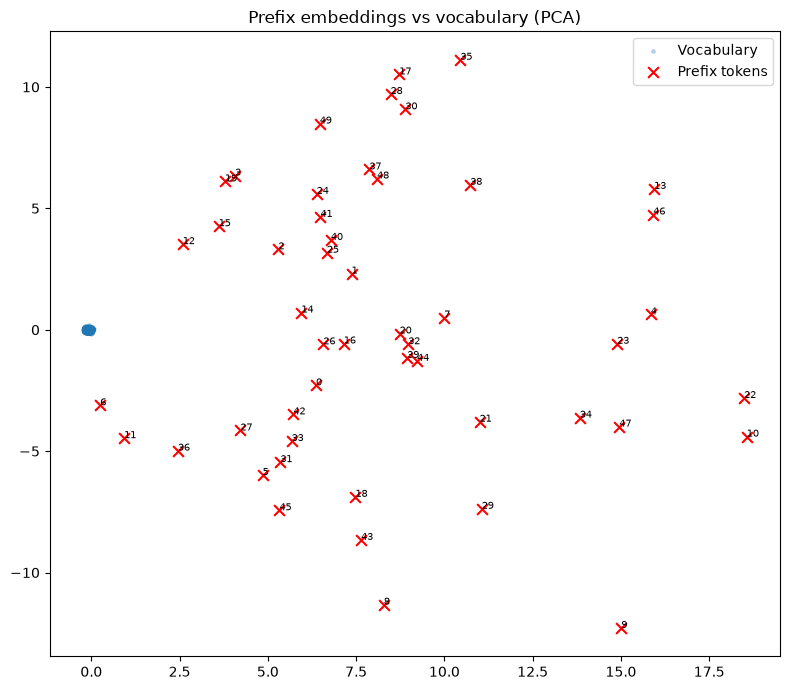

AVVIO ANALISI t-SNE


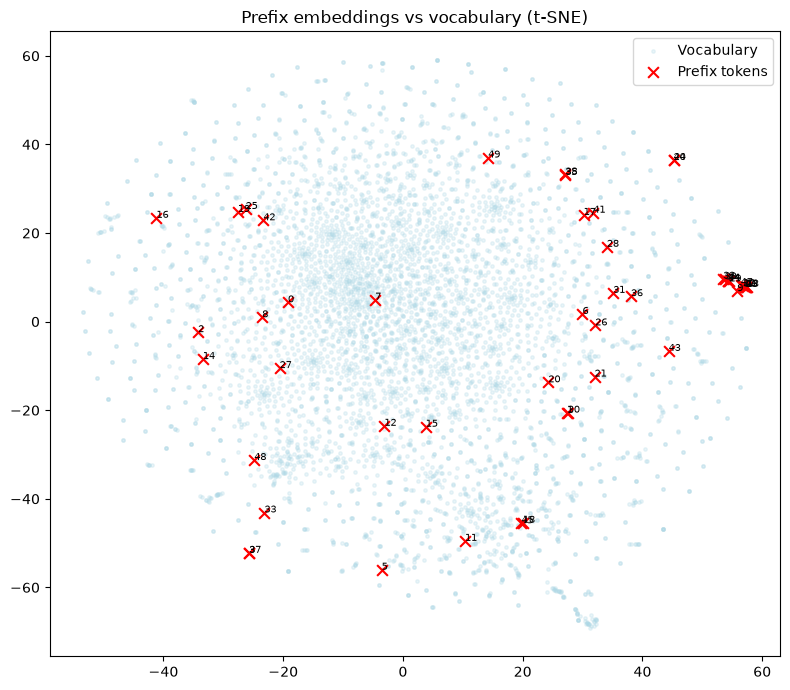

DISTRIBUZIONE SIMILARITÀ COSINALE


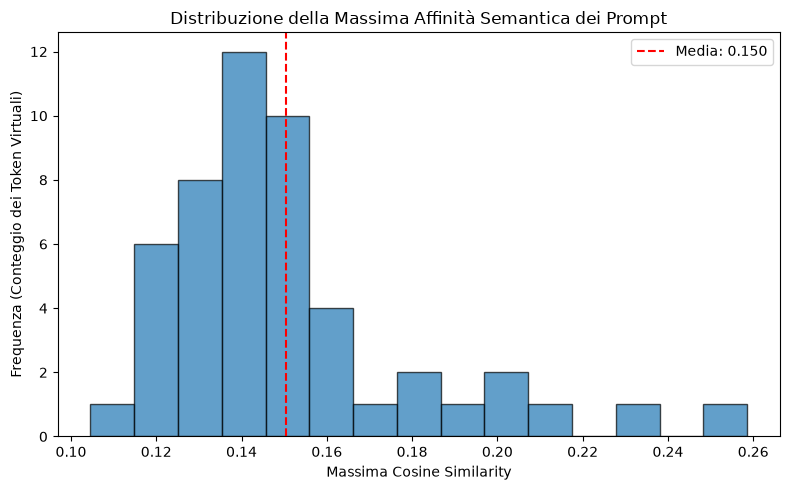

ANALISI DELLE MAPPE DI ATTENZIONE


C:\Users\Franco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


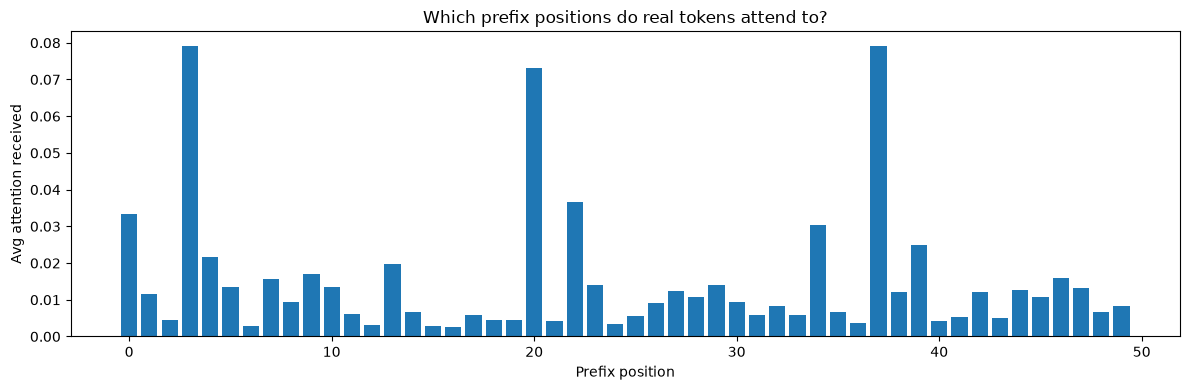

CALCOLO DELL'ENTROPIA DI SHANNON

Entropia Media dell'Attenzione verso i Prompt: 2.7290


In [13]:
print(f"AVVIO ANALISI PCA - batch size: {BATCH_SIZE}")
pca_analysis(model, file_name=file_name)

print("AVVIO ANALISI t-SNE")
tsne_analysis(model, file_name=file_name)

print("DISTRIBUZIONE SIMILARITÀ COSINALE")
cosine_similarity_distribution(model, file_name=file_name)

print("ANALISI DELLE MAPPE DI ATTENZIONE")
attention_analysis(model, val_loader, device, file_name=file_name)

print("CALCOLO DELL'ENTROPIA DI SHANNON")
attention_entropy_analysis(model, val_loader, device)

In [20]:
drops = ablation_analysis(model, val_loader, device, id_to_tag, file_name=file_name)

Converting DataLoader to batch list (this may take a moment)...


C:\Users\Franco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Baseline F1: 0.8424


KeyboardInterrupt: 

Estrazione completata: 50 soft token con dimensionalità 768


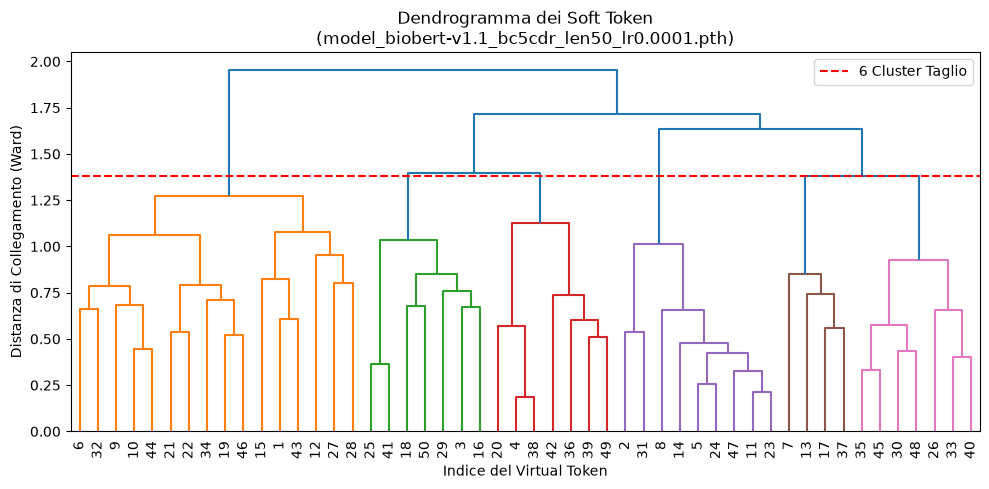

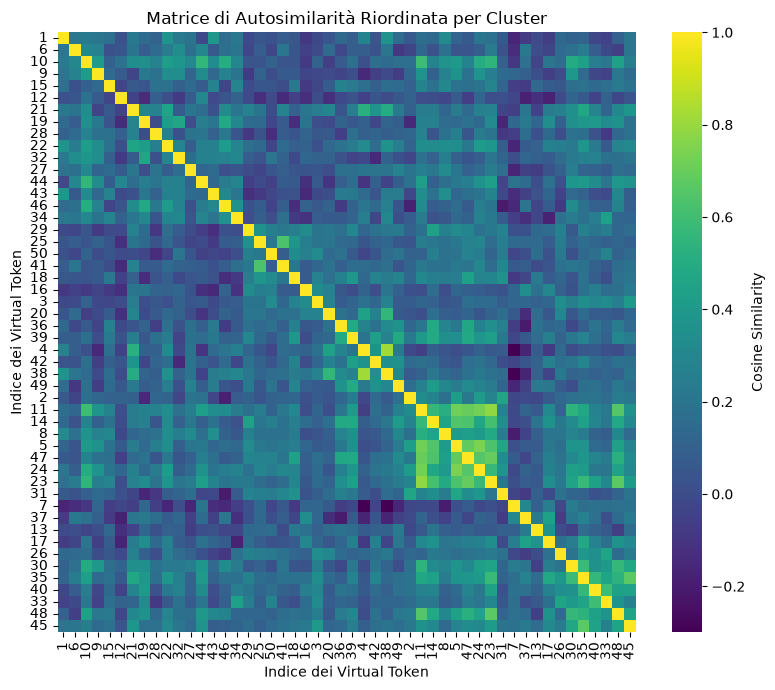


=== COMPOSIZIONE DEI CLUSTER STRUTTURALI ===
Cluster 01 (Dimensione: 16 token): [np.int64(1), np.int64(6), np.int64(9), np.int64(10), np.int64(12), np.int64(15), np.int64(19), np.int64(21), np.int64(22), np.int64(27), np.int64(28), np.int64(32), np.int64(34), np.int64(43), np.int64(44), np.int64(46)]
Cluster 02 (Dimensione: 7 token): [np.int64(3), np.int64(16), np.int64(18), np.int64(25), np.int64(29), np.int64(41), np.int64(50)]
Cluster 03 (Dimensione: 7 token): [np.int64(4), np.int64(20), np.int64(36), np.int64(38), np.int64(39), np.int64(42), np.int64(49)]
Cluster 04 (Dimensione: 9 token): [np.int64(2), np.int64(5), np.int64(8), np.int64(11), np.int64(14), np.int64(23), np.int64(24), np.int64(31), np.int64(47)]
Cluster 05 (Dimensione: 4 token): [np.int64(7), np.int64(13), np.int64(17), np.int64(37)]
Cluster 06 (Dimensione: 7 token): [np.int64(26), np.int64(30), np.int64(33), np.int64(35), np.int64(40), np.int64(45), np.int64(48)]


(array([1, 4, 2, 3, 4, 1, 5, 4, 1, 1, 4, 1, 5, 4, 1, 2, 5, 2, 1, 3, 1, 1,
        4, 4, 2, 6, 1, 1, 2, 6, 4, 1, 6, 1, 6, 3, 5, 3, 3, 6, 2, 3, 1, 1,
        6, 1, 4, 6, 3, 2], dtype=int32),
 array([[ 1.        ,  0.05680928, -0.01104216, ...,  0.09693808,
          0.15315148,  0.02090462],
        [ 0.05680928,  0.9999999 ,  0.07399978, ...,  0.2371461 ,
          0.16318476,  0.10316728],
        [-0.01104216,  0.07399978,  1.0000002 , ...,  0.2530334 ,
          0.07048827,  0.31489426],
        ...,
        [ 0.09693808,  0.2371461 ,  0.2530334 , ...,  1.        ,
          0.22204891,  0.1044298 ],
        [ 0.15315148,  0.16318476,  0.07048827, ...,  0.22204891,
          1.        ,  0.19705226],
        [ 0.02090462,  0.10316728,  0.31489426, ...,  0.1044298 ,
          0.19705226,  0.99999994]], shape=(50, 50), dtype=float32))

In [18]:
cluster_soft_tokens(model, file_name=file_name, n_clusters=6)

In [ ]:

from scipy.spatial.distance import squareform

def analizza_e_correlazione_cluster_knn(model, tokenizer, n_clusters=3, k_neighbors=5, top_n_vocab=10, file_name):
    """
    Esegue il clustering gerarchico dei soft token e correla i risultati 
    con l'analisi KNN (sia interna tra soft token che esterna verso il vocabolario).
    """
    model.eval()
    with torch.no_grad():
        # 1. Estrazione Embedding dei Soft Token (L x H)
        soft_embeddings = model.prefix_module(bsz=1).squeeze(0).cpu().numpy()
        
        # 2. Estrazione Embedding del Vocabolario di BioBERT
        vocab_embeddings = model.encoder.get_input_embeddings().weight.data.cpu().numpy()
    
    L, H = soft_embeddings.shape
    
    # Preparazione lista per i log di testo
    log_lines = []
    
    print(f"Estrazione completata: {L} soft token rilevati.")
    log_lines.append(f"Estrazione completata: {L} soft token rilevati.")
    
    # CLUSTERING GERARCHICO
    similarity_matrix = cosine_similarity(soft_embeddings)
    distance_matrix = np.clip(1.0 - similarity_matrix, 0.0, 2.0)
    
    condensed_distances = squareform(distance_matrix, checks=False)
    Z = linkage(condensed_distances, method='ward')
    cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    
    # CALCOLO METRICHE DI CORRELAZIONE KNN
    coerenza_totale = []
    coerenza_per_cluster = {c: [] for c in range(1, n_clusters + 1)}
    
    for i in range(L):
        # KNN Interno: Trova i k vicini più simili tra i soft token (escludendo se stesso)
        nearest_soft = np.argsort(similarity_matrix[i])[::-1][1:k_neighbors+1]
        
        cluster_corrente = cluster_labels[i]
        cluster_vicini = cluster_labels[nearest_soft]
        
        # Calcolo di quanti vicino allo stesso cluster
        stesso_cluster = np.sum(cluster_vicini == cluster_corrente)
        purezza_vicinato = stesso_cluster / k_neighbors
        
        coerenza_totale.append(purezza_vicinato)
        coerenza_per_cluster[cluster_corrente].append(purezza_vicinato)
    
    line = "ANALISI DI COERENZA LOCALE (KNN) VS STRUTTURA GLOBALE (CLUSTER)"
    print(line); log_lines.append(line)
    
    line = f"Purezza media dei {k_neighbors}-vicini sull'intero set: {np.mean(coerenza_totale)*100:.2f}%"
    print(line); log_lines.append(line)
    
    for c in range(1, n_clusters + 1):
        line = f"  -> Purezza media nel Cluster {c:02d}: {np.mean(coerenza_per_cluster[c])*100:.2f}%"
        print(line); log_lines.append(line)
        
    # CARATTERIZZAZIONE SEMANTICA DEI CLUSTER (VOCABOLARIO KNN)
    line = "INTERPRETAZIONE SEMANTICA DEI CLUSTER TRAMITE VOCABOLARIO"
    print(line); log_lines.append(line)
    
    for c in range(1, n_clusters + 1):
        indices_in_cluster = np.where(cluster_labels == c)[0]
        
        line = f"\\ CLUSTER {c:02d} (Dimensione: {len(indices_in_cluster)} token)"
        print(line); log_lines.append(line)
        
        line = f"Virtual Token inclusi: {list(indices_in_cluster + 1)}"
        print(line); log_lines.append(line)
        
        # Calcoliamo il centroide del cluster per estrarre parole chiave globali del gruppo
        centroide = soft_embeddings[indices_in_cluster].mean(axis=0).reshape(1, -1)
        
        # KNN verso il vocabolario reale del modello
        vocab_sim = cosine_similarity(centroide, vocab_embeddings).squeeze()
        top_vocab_indices = np.argsort(vocab_sim)[::-1][:top_n_vocab]
        
        parole_chiave = []
        for idx in top_vocab_indices:
            parola = tokenizer.decode([idx]).strip()
            score = vocab_sim[idx]
            parole_chiave.append(f"'{parola}' (sim: {score:.3f})")
            
        line = f"Top {top_n_vocab} parole reali più vicine al centroide del cluster:"
        print(line); log_lines.append(line)
        
        line = "  " + ", ".join(parole_chiave)
        print(line); log_lines.append(line)
        
    # Salvataggio del file di testo
    file_name = file_name.removesuffix(".pth")
    os.makedirs("output_analysis", exist_ok=True)
    with open("output_analysis/heatmap_cluster_knn_" + file_name + ".txt", "w", encoding="utf-8") as f:
        f.write("\n".join(log_lines) + "\n")
        
    # VISUALIZZAZIONE DELLA HEATMAP CON ETICHETTE CLUSTER
    sorted_indices = np.argsort(cluster_labels)
    sorted_similarity = similarity_matrix[sorted_indices][:, sorted_indices]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(sorted_similarity, 
                cmap='viridis', 
                xticklabels=sorted_indices + 1, 
                yticklabels=sorted_indices + 1,
                cbar_kws={'label': 'Cosine Similarity'})
    
    # Disegna linee di demarcazione visiva per i cluster sulla heatmap
    linee_separazione = np.where(np.diff(cluster_labels[sorted_indices]) != 0)[0] + 1
    for linea in linee_separazione:
        plt.axhline(y=linea, color='red', linestyle='--', alpha=0.7)
        plt.axvline(x=linea, color='red', linestyle='--', alpha=0.7)
        
    plt.title("Matrice di Autosimilarità Riordinata con Confini dei Cluster")
    plt.xlabel("Indice dei Virtual Token")
    plt.ylabel("Indice dei Virtual Token")
    plt.tight_layout()
    plt.savefig("output_analysis/heatmap_cluster_knn_" + file_name + ".png", dpi=120)
    plt.show()

    return cluster_labels, similarity_matrix

CORRELAZIONE CLUSTER-KNN
Estrazione completata: 50 soft token rilevati.
ANALISI DI COERENZA LOCALE (KNN) VS STRUTTURA GLOBALE (CLUSTER)
Purezza media dei 5-vicini sull'intero set: 58.80%
  -> Purezza media nel Cluster 01: 52.50%
  -> Purezza media nel Cluster 02: 40.00%
  -> Purezza media nel Cluster 03: 54.29%
  -> Purezza media nel Cluster 04: 88.89%
  -> Purezza media nel Cluster 05: 40.00%
  -> Purezza media nel Cluster 06: 68.57%
INTERPRETAZIONE SEMANTICA DEI CLUSTER TRAMITE VOCABOLARIO
\ CLUSTER 01 (Dimensione: 16 token)
Virtual Token inclusi: [np.int64(1), np.int64(6), np.int64(9), np.int64(10), np.int64(12), np.int64(15), np.int64(19), np.int64(21), np.int64(22), np.int64(27), np.int64(28), np.int64(32), np.int64(34), np.int64(43), np.int64(44), np.int64(46)]
Top 10 parole reali più vicine al centroide del cluster:
  'survival' (sim: 0.153), '##sors' (sim: 0.140), 'influx' (sim: 0.127), 'Survivor' (sim: 0.126), '##vigator' (sim: 0.125), '」' (sim: 0.122), '[unused86]' (sim: 0.12

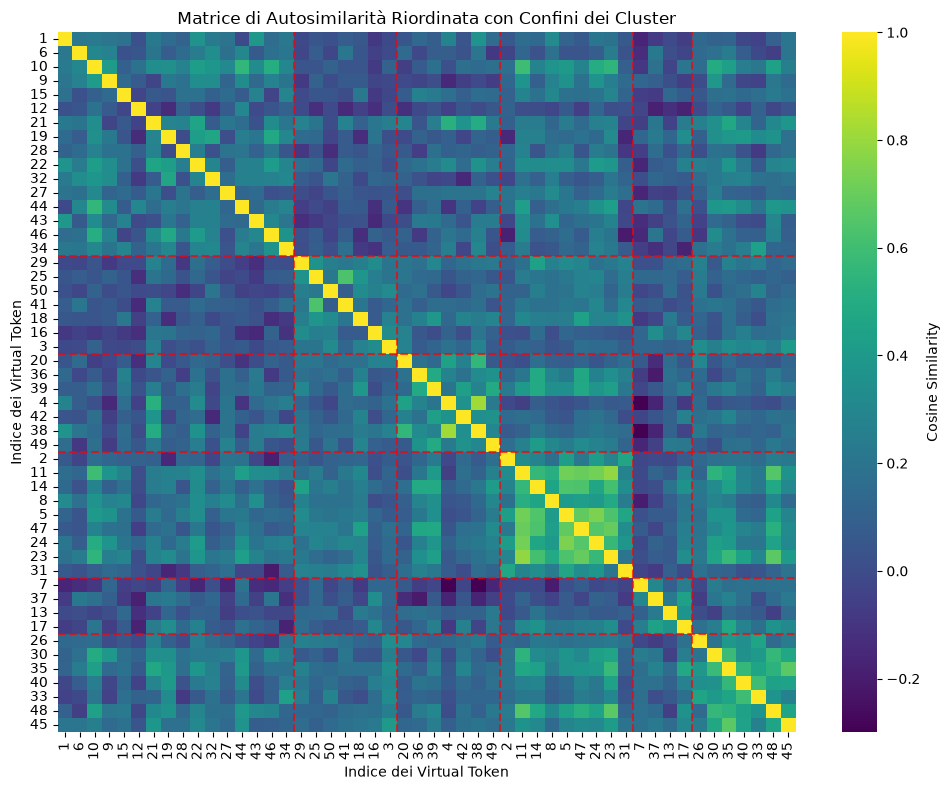

In [19]:
print("CORRELAZIONE CLUSTER-KNN")
labels, sim_mat = analizza_e_correlazione_cluster_knn(model, tokenizer, n_clusters=6, file_name=file_name)

In [34]:
print("REPORT PER CLASSE")
report_df, y_true, y_pred = per_class_report(model, val_loader, device, id_to_tag)

REPORT PER CLASSE


C:\Users\Franco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


,label,precision,recall,f1,support
1,DISEASE,0.743064,0.840956,0.788985,4395
3,macro avg,0.812089,0.868587,0.838793,9762
2,micro avg,0.815298,0.871338,0.842387,9762
4,weighted avg,0.818962,0.871338,0.843753,9762
0,CHEMICAL,0.881114,0.896218,0.888602,5367


In [36]:
print("PARAMETRI ADDESTRABILI")
params_df = trainable_parameter_report(model)

PARAMETRI ADDESTRABILI
Parametri totali: 109,140,229
Parametri addestrabili: 829,957 (0.7605%)


,module,n_params,share_of_trainable
1,prefix_module,826112,0.995367
0,classifier,3845,0.004633


In [37]:
print("CONFRONTO PREFIX VS SOFT PROMPT")
peft_df, peft_best, peft_pivot = compare_peft_results("results/final")

CONFRONTO PREFIX VS SOFT PROMPT


,Method,Model,Dataset,Token_Length,Learning_Rate,Micro Avg F1-Score
0,prefix,bert-base-uncased,disi-unibo-nlp/AnatEM,10,0.0010,0.8274
6,soft_prompt,bert-base-uncased,disi-unibo-nlp/AnatEM,50,0.0010,0.7802
3,prefix,dmis-lab/biobert-v1.1,disi-unibo-nlp/AnatEM,50,0.0001,0.8695
9,soft_prompt,dmis-lab/biobert-v1.1,disi-unibo-nlp/AnatEM,50,0.0010,0.8283
12,soft_prompt,medicalai/ClinicalBERT,disi-unibo-nlp/AnatEM,50,0.0010,0.7723
1,prefix,bert-base-uncased,disi-unibo-nlp/JNLPBA,10,0.0010,0.7119
7,soft_prompt,bert-base-uncased,disi-unibo-nlp/JNLPBA,50,0.0010,0.6705
4,prefix,dmis-lab/biobert-v1.1,disi-unibo-nlp/JNLPBA,10,0.0001,0.7409
10,soft_prompt,dmis-lab/biobert-v1.1,disi-unibo-nlp/JNLPBA,50,0.0001,0.7134
13,soft_prompt,medicalai/ClinicalBERT,disi-unibo-nlp/JNLPBA,50,0.0001,0.6286


Method                                        prefix  soft_prompt  \
Model                  Dataset                                      
bert-base-uncased      disi-unibo-nlp/AnatEM  0.8274       0.7802   
                       disi-unibo-nlp/bc5cdr  0.8255       0.7837   
                       disi-unibo-nlp/JNLPBA  0.7119       0.6705   
dmis-lab/biobert-v1.1  disi-unibo-nlp/AnatEM  0.8695       0.8283   
                       disi-unibo-nlp/bc5cdr  0.8677       0.8373   
                       disi-unibo-nlp/JNLPBA  0.7409       0.7134   
medicalai/ClinicalBERT disi-unibo-nlp/AnatEM     NaN       0.7723   
                       disi-unibo-nlp/JNLPBA     NaN       0.6286   
                       disi-unibo-nlp/bc5cdr     NaN       0.7668   

Method                                        prefix_minus_soft  
Model                  Dataset                                   
bert-base-uncased      disi-unibo-nlp/AnatEM             0.0472  
                       disi-unibo-nlp/bc5cdr             0.0418  
                       disi-unibo-nlp/JNLPBA             0.0414  
dmis-lab/biobert-v1.1  disi-unibo-nlp/AnatEM             0.0412  
                       disi-unibo-nlp/bc5cdr             0.0304  
                       disi-unibo-nlp/JNLPBA             0.0275  
medicalai/ClinicalBERT disi-unibo-nlp/AnatEM                NaN  
                       disi-unibo-nlp/JNLPBA                NaN  
                       disi-unibo-nlp/bc5cdr                NaN

In [38]:
print("CONFRONTO PEFT VS FULL FINE-TUNING")
combined_results_df, baseline_df, peft_baseline_pivot = compare_peft_with_baseline("results/final", "baseline_version")

CONFRONTO PEFT VS FULL FINE-TUNING


,Method,Model,Dataset,Learning_Rate,Micro Avg F1-Score
0,prefix,bert-base-uncased,disi-unibo-nlp/AnatEM,0.00100,0.8274
6,soft_prompt,bert-base-uncased,disi-unibo-nlp/AnatEM,0.00100,0.7802
3,prefix,dmis-lab/biobert-v1.1,disi-unibo-nlp/AnatEM,0.00010,0.8695
9,soft_prompt,dmis-lab/biobert-v1.1,disi-unibo-nlp/AnatEM,0.00100,0.8283
12,soft_prompt,medicalai/ClinicalBERT,disi-unibo-nlp/AnatEM,0.00100,0.7723
1,prefix,bert-base-uncased,disi-unibo-nlp/JNLPBA,0.00100,0.7119
7,soft_prompt,bert-base-uncased,disi-unibo-nlp/JNLPBA,0.00100,0.6705
4,prefix,dmis-lab/biobert-v1.1,disi-unibo-nlp/JNLPBA,0.00010,0.7409
10,soft_prompt,dmis-lab/biobert-v1.1,disi-unibo-nlp/JNLPBA,0.00010,0.7134
13,soft_prompt,medicalai/ClinicalBERT,disi-unibo-nlp/JNLPBA,0.00010,0.6286


Method                                        full_finetuning  prefix  \
Model                  Dataset                                          
bert-base-uncased      disi-unibo-nlp/AnatEM              NaN  0.8274   
                       disi-unibo-nlp/JNLPBA              NaN  0.7119   
                       disi-unibo-nlp/bc5cdr              NaN  0.8255   
dmis-lab/biobert-v1.1  disi-unibo-nlp/AnatEM              NaN  0.8695   
                       disi-unibo-nlp/JNLPBA              NaN  0.7409   
                       disi-unibo-nlp/anatem           0.8619     NaN   
                       disi-unibo-nlp/bc5cdr           0.8716  0.8677   
                       disi-unibo-nlp/jnlpba           0.7371     NaN   
medicalai/ClinicalBERT disi-unibo-nlp/AnatEM              NaN     NaN   
                       disi-unibo-nlp/JNLPBA              NaN     NaN   
                       disi-unibo-nlp/bc5cdr              NaN     NaN   

Method                                        soft_prompt  prefix_minus_full  \
Model                  Dataset                                                 
bert-base-uncased      disi-unibo-nlp/AnatEM       0.7802                NaN   
                       disi-unibo-nlp/JNLPBA       0.6705                NaN   
                       disi-unibo-nlp/bc5cdr       0.7837                NaN   
dmis-lab/biobert-v1.1  disi-unibo-nlp/AnatEM       0.8283                NaN   
                       disi-unibo-nlp/JNLPBA       0.7134                NaN   
                       disi-unibo-nlp/anatem          NaN                NaN   
                       disi-unibo-nlp/bc5cdr       0.8373            -0.0039   
                       disi-unibo-nlp/jnlpba          NaN                NaN   
medicalai/ClinicalBERT disi-unibo-nlp/AnatEM       0.7723                NaN   
                       disi-unibo-nlp/JNLPBA       0.6286                NaN   
                       disi-unibo-nlp/bc5cdr       0.7668                NaN   

Method                                        soft_prompt_minus_full  
Model                  Dataset                                        
bert-base-uncased      disi-unibo-nlp/AnatEM                     NaN  
                       disi-unibo-nlp/JNLPBA                     NaN  
                       disi-unibo-nlp/bc5cdr                     NaN  
dmis-lab/biobert-v1.1  disi-unibo-nlp/AnatEM                     NaN  
                       disi-unibo-nlp/JNLPBA                     NaN  
                       disi-unibo-nlp/anatem                     NaN  
                       disi-unibo-nlp/bc5cdr                 -0.0343  
                       disi-unibo-nlp/jnlpba                     NaN  
medicalai/ClinicalBERT disi-unibo-nlp/AnatEM                     NaN  
                       disi-unibo-nlp/JNLPBA                     NaN  
                       disi-unibo-nlp/bc5cdr                     NaN

HEATMAP IPERPARAMETRI PER CONFIGURAZIONE CORRENTE


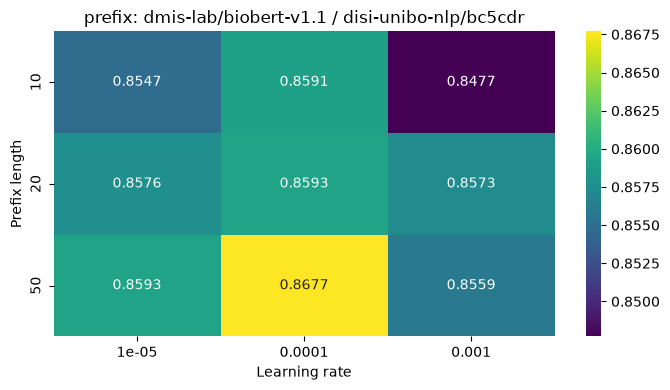

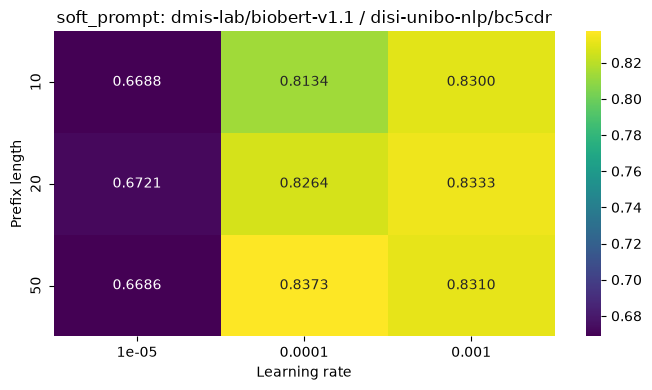

In [39]:
print("HEATMAP IPERPARAMETRI PER CONFIGURAZIONE CORRENTE")
hyperparameter_heatmaps(peft_df, method="prefix", model_name=MODEL_NAME, dataset_name=DATASET_NAME)
hyperparameter_heatmaps(peft_df, method="soft_prompt", model_name=MODEL_NAME, dataset_name=DATASET_NAME)

In [ ]:

print("ABLATION CUMULATIVA")
cumulative_ablation_df = cumulative_ablation_analysis(model, val_loader, device, id_to_tag, drops=drops)

